## imports and defalt

## pygama

In [1]:
import numpy as np
import pygama.pargen.energy_cal as pgc
import pygama.pargen.survival_fractions as sf


In [2]:
from pytools4scarf import dataloader

In [3]:
from pathlib import Path
runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1m', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
]

map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s100ns_mw5')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s100ns_mw5.yaml'

In [ ]:
candidate ='s500ns_mw3'

dfs_sit_candidate, lts_sit_candidate = {}, {}

dfs_sit_candidate["r057"], lts_sit_candidate["r057"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)
dfs_sit_candidate["r061"], lts_sit_candidate["r061"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r061",
    "cal",
    ["ch002"],
)
dfs_sit_candidate["r064"], lts_sit_candidate["r064"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r064",
    "cal",
    ["ch002"],
)

No files to load found!


In [14]:
default = "s100ns_mw5"
dfs_sit_default, lts_sit_default = {}, {}

dfs_sit_default["r057"], lts_sit_default["r057"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(default),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)

dfs_sit_default["r061"], lts_sit_default["r061"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(default),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r061",
    "cal",
    ["ch002"],
)


In [17]:
aoe_array = np.concatenate([np.asarray(dfs_sit_candidate["r057"]["ch002"].A_max_mw_o_E_fix_Classifier),np.asarray(dfs_sit_candidate["r061"]["ch002"].A_max_mw_o_E_fix_Classifier)])
# low_cut_array = np.asarray(dfs_sit_candidate["r057"]["ch002"].A_max_mw_o_E_fix_Low_Cut)
energy_array = np.concatenate([np.asarray(dfs_sit_candidate["r057"]["ch002"].trapEftp_fix_cal),np.asarray(dfs_sit_candidate["r061"]["ch002"].trapEftp_fix_cal)])
is_valid_waveform = np.concatenate([np.asarray(dfs_sit_candidate["r057"]["ch002"].is_valid_waveform),np.asarray(dfs_sit_candidate["r061"]["ch002"].is_valid_waveform)])

# Alpha_mask = np.asarray(
#     (dfs_sit_default["r057"]["ch002"].A_max_mw_o_E_fix_Classifier<3)
#     &(dfs_sit_default["r057"]["ch002"].Iasy<0) 
# )
# aoe_array = np.asarray(dfs_sit_candidate["r057"]["ch002"].A_max_mw_o_E_fix_Classifier[Alpha_mask])
# low_cut_array = np.asarray(dfs_sit_candidate["r057"]["ch002"].A_max_mw_o_E_fix_Low_Cut[Alpha_mask])
# energy_array = np.asarray(dfs_sit_candidate["r057"]["ch002"].trapEftp_fix_cal[Alpha_mask])
# is_valid_waveform = np.asarray(dfs_sit_candidate["r057"]["ch002"].is_valid_waveform[Alpha_mask])


In [18]:

fitrange_dep = (1565, 1615)
peak_dep = 1592.5


mask_dep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_dep[0])
    & (energy_array < fitrange_dep[1])
    & is_valid_waveform
    )

E_fit_dep = energy_array[mask_dep]
aoe_fit_dep = aoe_array[mask_dep]

print("E_fit_dep:", len(E_fit_dep))
print("aoe_fit_dep:", len(aoe_fit_dep))


fitrange_sep = (2070, 2140)

peak_sep =2103.5


mask_sep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_sep[0])
    & (energy_array < fitrange_sep[1])
    & is_valid_waveform
)

E_fit_sep = energy_array[mask_sep]
aoe_fit_sep = aoe_array[mask_sep]

fitrange_fep =  (2580, 2645)
peak_fep = 2614.5
mask_fep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_fep[0])
    & (energy_array < fitrange_fep[1])
    & is_valid_waveform
)
E_fit_fep = energy_array[mask_fep]
aoe_fit_fep = aoe_array[mask_fep] 


E_fit_dep: 21104
aoe_fit_dep: 21104


In [ ]:
# pars, errs, cov, cs, func_used, mask_fit, valid, minuit_obj = pgc.unbinned_staged_energy_fit(
#     E_fit_fep,
#     sf.gauss_on_step,          # or sf.hpge_peak
#     guess_func=sf.energy_guess,
#     bounds_func=sf.get_bounds,
#     # guess_kwargs={"peak": peak, "eres": eres_pars},
#     fit_range=fitrange_fep,
#     display=2,
# )
# print(pars)
# print(errs)
# print("returned cs =", cs)
# print("returned valid =", valid)
# print("returned values:")


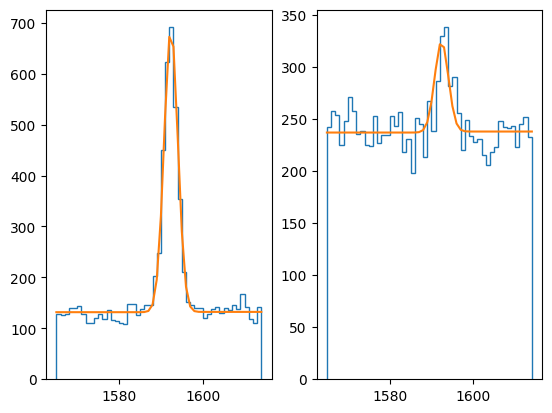

survival fraction dep = 86.50079143095456
survival fraction error = 1.3274126307202372


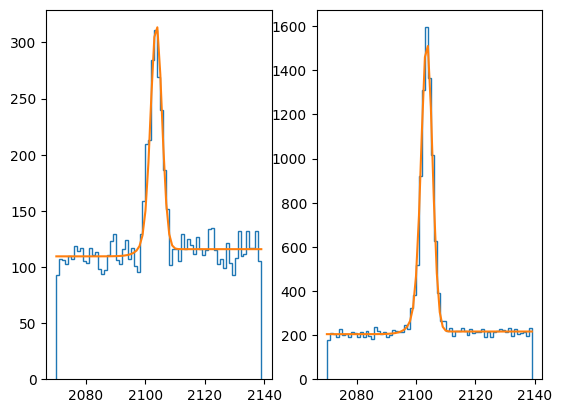

survival fraction sep= 13.373130235698099
survival fraction error = 0.5432880758061656


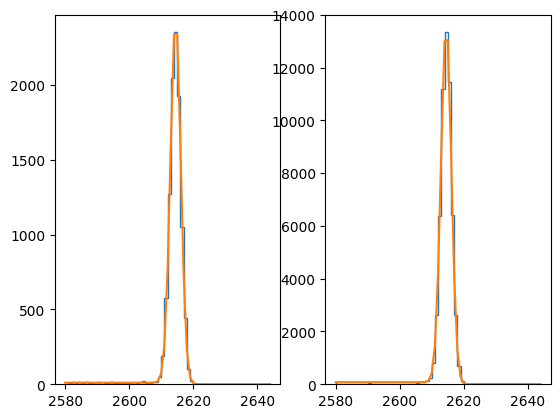

survival fraction fep= 15.238441970311257
survival fraction error = 0.1411639128271816


In [22]:
import pygama.pargen.survival_fractions as sf
# from pygama.math.functions import gauss_on_step
cut_value = -0.95
sf_val_dep, sf_err_dep, values_dep, errors_dep = sf.get_survival_fraction(
    energy=E_fit_dep,
    cut_param=aoe_fit_dep,
    cut_val=cut_value,
    peak=peak_dep,        # DEP peak
    fit_range=fitrange_dep,
    func=sf.gauss_on_step,
    mode="greater",
    display=2,
    eres_pars=1
)
print("survival fraction dep =", sf_val_dep)
print("survival fraction error =", sf_err_dep)

sf_val_sep, sf_err_sep, values_sep, errors_sep = sf.get_survival_fraction(
    energy=E_fit_sep,
    cut_param=aoe_fit_sep,
    cut_val=cut_value,      
    peak=peak_sep,        # SEP peak
    fit_range=fitrange_sep,
    func=sf.hpge_peak,
    mode="greater",
    display=2,
    eres_pars=1
)
print("survival fraction sep=", sf_val_sep)
print("survival fraction error =", sf_err_sep) 

sf_val_fep, sf_err_fep, values_fep, errors_fep = sf.get_survival_fraction(
    energy=E_fit_fep,
    cut_param=aoe_fit_fep,
    cut_val=cut_value,      
    peak=peak_fep,        # FEP peak
    fit_range=fitrange_fep,
    func=sf.hpge_peak,
    mode="greater",
    display=2,
    eres_pars=1
)
print("survival fraction fep=", sf_val_fep)
print("survival fraction error =", sf_err_fep)    

## find cut values

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_sf_from_run_linear_interpolation(energy_array=None,aoe_array=None,is_valid_waveform=None, n_points=50, target_sf=90.0):
    # print(f"Calculating survival fraction (Interpolation) for {run} ...")
    if energy_array is None:
        # print("missing energy array")
        raise ValueError("missing energy array")
    if aoe_array is None:
        raise ValueError("missing aoe array")
    if is_valid_waveform is None:
        raise ValueError("missing valid waveform mask array")
    energy_array = energy_array
    aoe_array = aoe_array
    is_valid_waveform = is_valid_waveform
    
    # 定义峰和范围
    fit_configs = {
        "dep": {"range": (1565, 1615), "peak": 1592.5},
        "sep": {"range": (2070, 2140), "peak": 2103.5},
        "fep": {"range": (2580, 2645), "peak": 2614.5}
    }

    def get_mask(cfg):
        return (np.isfinite(energy_array) & np.isfinite(aoe_array) & 
                (energy_array > cfg["range"][0]) & (energy_array < cfg["range"][1]) & 
                is_valid_waveform)

    # 提取各峰数据
    masks = {k: get_mask(v) for k, v in fit_configs.items()}
    E_fit = {k: energy_array[m] for k, m in masks.items()}
    aoe_fit = {k: aoe_array[m] for k, m in masks.items()}

    # --- 2. 线性插值采样 (DEP 峰) ---
    cut_grid = np.linspace(-4, 0, n_points)
    sf_list = []
    sf_err_list = []

    print(f"Sampling {n_points} points from -4 to 0...")
    for cv in cut_grid:
        res = sf.get_survival_fraction(
            energy=E_fit["dep"], cut_param=aoe_fit["dep"],
            cut_val=cv, peak=fit_configs["dep"]["peak"],
            fit_range=fit_configs["dep"]["range"],
            func=sf.hpge_peak, mode="greater", display=0, eres_pars=3
        )
        sf_list.append(res[0])      # sf_mid
        sf_err_list.append(res[1])  # sf_err_mid

    sf_list = np.array(sf_list)
    sf_err_list = np.array(sf_err_list)

    # --- 3. 执行线性插值找到 Target SF (90%) ---
    # 假设 SF 随 Cut 增加而减小 (mode="greater")
    if target_sf > sf_list[0] or target_sf < sf_list[-1]:
        print(f"Warning: target_sf {target_sf} is outside the sampled range [{sf_list[-1]:.2}, {sf_list[0]:.2}]")
    
    # 使用 np.interp 需要输入 x 是递增的，所以如果 sf 是递减的需要翻转
    # 或者手动找交叉点 (更稳妥)
    idx = np.where(sf_list <= target_sf)[0][0] # 找到第一个跌破 90 的点
    i1, i2 = idx - 1, idx
    x1, x2 = cut_grid[i1], cut_grid[i2]
    y1, y2 = sf_list[i1], sf_list[i2]

    # 线性插值公式: x = x1 + (target_y - y1) * (x2 - x1) / (y2 - y1)
    cut_value_90 = x1 + (target_sf - y1) * (x2 - x1) / (y2 - y1)
    
    # 对应的误差也进行线性插值
    sf_err_90 = np.interp(cut_value_90, cut_grid, sf_err_list)
    
    # --- 4. 计算 SEP 和 FEP 在该 Cut 下的存活率 ---
    def get_final_sf(peak_key):
        return sf.get_survival_fraction(
            energy=E_fit[peak_key], cut_param=aoe_fit[peak_key],
            cut_val=cut_value_90, peak=fit_configs[peak_key]["peak"],
            fit_range=fit_configs[peak_key]["range"],
            func=sf.hpge_peak, mode="greater", display=0, eres_pars=3
        )
    sf_val_dep, sf_err_dep, _, _ = get_final_sf("dep")
    sf_val_sep, sf_err_sep, _, _ = get_final_sf("sep")
    sf_val_fep, sf_err_fep, _, _ = get_final_sf("fep")

    # --- 5. 绘图 ---
    plt.figure(figsize=(8, 6))
    plt.errorbar(cut_grid, sf_list, yerr=sf_err_list, fmt='o-', capsize=3, label='DEP Survival Fraction')
    plt.axhline(target_sf, color='r', linestyle='--', label=f'Target {target_sf}%')
    plt.axvline(cut_value_90, color='g', linestyle='--', label=f'Cut @ {target_sf}% = {cut_value_90:.4f}')
    
    plt.xlabel('A/E Cut Value')
    plt.ylabel('Survival Fraction (%)')
    # plt.title(f'Run {run}: SF vs A/E Cut (DEP Peak)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Interpolated cut for {target_sf}% SF: {cut_value_90:.6f}")
    
    # 返回与原函数格式一致的信息
    # 注意：原代码返回了 8 个值，这里保持顺序一致
    return (target_sf,cut_value_90, sf_err_90, sf_val_dep, sf_err_dep, 
            sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep)

In [ ]:
sf_db = {}
sf_db.setdefault(candidate, {})
for percentage in np.linspace(90,100,5,endpoint=False,dtype=int):
    print(f'calculating cut values for {percentage}% sf of DEP with {candidate}')
    target_sf,cut_value_90, sf_err_90, sf_val_dep, sf_err_dep, sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep=get_sf_from_run_linear_interpolation(energy_array=energy_array,is_valid_waveform=is_valid_waveform,aoe_array=aoe_array,n_points=50,target_sf=percentage)
    sf_db[candidate][str(percentage)] = {
    "target_sf": target_sf,
    "cut_value": cut_value_90,
    "sf_err_90": sf_err_90,
    "sf_val_dep": sf_val_dep,
    "sf_err_dep": sf_err_dep,
    "sf_val_sep": sf_val_sep,
    "sf_err_sep": sf_err_sep,
    "sf_val_fep": sf_val_fep,
    "sf_err_fep": sf_err_fep,
    }


In [ ]:
import pickle
from pathlib import Path
# fitrange_dep = (1565, 1615)
# peak_dep = 1592.5
# fitrange_fep =  (2580, 2645)
# peak_fep = 2614.5
# fitrange_sep = (2070, 2140)
# peak_sep =2103.5


In [ ]:
outpath = Path(f"vary_dep_SF_{candidate}_bg.pkl")

# with open(outpath, "wb") as f:
#     pickle.dump(sf_db, f)

# print("saved to:", outpath.resolve())

In [ ]:
sf_db.keys()
sf_db['s500ns_mw3'].keys()

## now lets calculate the combinde sf

In [ ]:
candidate ='s500ns_mw3'
candidate_2 = 's40ns_mw7'

dfs_sit_candidate, lts_sit_candidate = {}, {}

dfs_sit_candidate["r057"], lts_sit_candidate["r057"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)
dfs_sit_candidate_2, lts_sit_candidate_2 = {}, {}

dfs_sit_candidate_2["r057"], lts_sit_candidate_2["r057"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate_2),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)

# dfs_sit_default, lts_sit_default = {},{}
# default = 's100ns_mw5'
# dfs_sit_default["r057"], lts_sit_default["r057"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(default),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r057",
#     "cal",
#     ["ch002"],
# )


In [12]:
import pickle
path = '/mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/vary_dep_SF_s500ns_mw3.pkl'
with open(path, "rb") as file:
    sf_db = pickle.load(file)
with open("/mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/scalib_survival_db_yaml.pkl", "rb") as f:
    sit_survival_db = pickle.load(f)
for i in [90,92,94,96,98]: 
    print(sf_db['s500ns_mw3'][str(i)]['cut_value'])
    print(sf_db['s500ns_mw3'][str(i)]['sf_val_dep'])
    print(sf_db['s500ns_mw3'][str(i)]['sf_err_dep'])
for i in[candidate,candidate_2] :
    print(f"{sit_survival_db[i]['cut_value_90']} "+i)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/vary_dep_SF_s500ns_mw3.pkl'

In [ ]:
# def two_cuts(run1, run2):
## masks for dep sep fep
long_filter_dep_sf = '90'
if sf_db[candidate][long_filter_dep_sf]['cut_value'] is not None:
    print(sf_db[candidate][long_filter_dep_sf]['cut_value'])
else: print('not found')
fitrange_dep = (1565, 1615)
peak_dep = 1592.5
fitrange_sep = (2070, 2140)
peak_sep =2103.5
fitrange_fep =  (2580, 2645)
peak_fep = 2614.5

is_valid_waveform = np.asarray(dfs_sit_candidate["r057"]['ch002'].is_valid_waveform)
# np.array_equal(dfs_sit_candidate["r057"]['ch002'].is_valid_waveform,dfs_sit_candidate_2["r057"]['ch002'].is_valid_waveform)

# run1 
# E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run1][pathlist])
E_1 =  np.asarray(dfs_sit_candidate["r057"]['ch002'].trapEftp_fix_cal)
Iasy_std = np.asarray((dfs_sit_default["r057"]['ch002'].Iasy<0))
A_max_mw_o_E_Classifier_1=np.asarray(dfs_sit_candidate["r057"]['ch002'].A_max_mw_o_E_fix_Classifier)

# cut_value_1 = sf_results['cut_value_90'][run1]
# cut_value_2 = sf_results['cut_value_90'][run2]


# mask_dep_1 = (
#     np.isfinite(E_1)
#     & np.isfinite(A_max_mw_o_E_Classifier_1)
#     & (E_1 > fitrange_dep[0])
#     & (E_1 < fitrange_dep[1])
#     & is_valid_waveform)
# mask_dep_2 = (
#     np.isfinite(E_2)
#     & np.isfinite(A_max_mw_o_E_Classifier_2)
#     & (E_2 > fitrange_dep[0])
#     & (E_2 < fitrange_dep[1])
#     & is_valid_waveform)
# mask_sep_1 = (
#     np.isfinite(E_1)
#     & np.isfinite(A_max_mw_o_E_Classifier_1)
#     & (E_1 > fitrange_sep[0])
#     & (E_1 < fitrange_sep[1])
#     & is_valid_waveform
#     )
# mask_sep_2= (
#     np.isfinite(E_2)
#     & np.isfinite(A_max_mw_o_E_Classifier_2)
#     & (E_2 > fitrange_sep[0])
#     & (E_2 < fitrange_sep[1])
#     & is_valid_waveform
#     )
# mask_fep_1 = (
#     np.isfinite(E_1)
#     & np.isfinite(A_max_mw_o_E_Classifier_1)
#     & (E_1 > fitrange_fep[0])
#     & (E_1 < fitrange_fep[1])
#     & is_valid_waveform
#     )
# mask_fep_2= (
#     np.isfinite(E_2)
#     & np.isfinite(A_max_mw_o_E_Classifier_2)
#     & (E_2 > fitrange_fep[0])
#     & (E_2 < fitrange_fep[1])
#     & is_valid_waveform
#     )
# E_fit_dep = E_1[mask_dep_1]
# E_fit_sep = E_1[mask_sep_1]
# E_fit_fep = E_1[mask_fep_1]
# aoe_fit_dep_1 = A_max_mw_o_E_Classifier_1[mask_dep_1]
# aoe_fit_dep_2 = A_max_mw_o_E_Classifier_2[mask_dep_2]
# aoe_fit_sep_1 = A_max_mw_o_E_Classifier_1[mask_sep_1]
# aoe_fit_sep_2 = A_max_mw_o_E_Classifier_2[mask_sep_2]
# aoe_fit_fep_1 = A_max_mw_o_E_Classifier_1[mask_fep_1]
# aoe_fit_fep_2 = A_max_mw_o_E_Classifier_2[mask_fep_2]

# # DEP after two cuts
# sf_val_dep, sf_err_dep, _, _ = sf.get_survival_fraction_two_cuts(
#     energy=E_fit_dep,
#     cut_param_1=aoe_fit_dep_1,
#     cut_param_2=aoe_fit_dep_2,
#     cut_val_1=cut_value_1,
#     cut_val_2=cut_value_2,
#     peak=peak_dep,        # DEP peak
#     fit_range=fitrange_dep,
#     func=sf.hpge_peak,
#     mode="greater",
#     display=2,
#     eres_pars=3
# )
# ## SEP after two cuts
# sf_val_sep, sf_err_sep, _, _ = sf.get_survival_fraction_two_cuts(
#     energy=E_fit_sep,
#     cut_param_1=aoe_fit_sep_1,
#     cut_param_2=aoe_fit_sep_2,
#     cut_val_1=cut_value_1,
#     cut_val_2=cut_value_2,
#     peak=peak_sep,        # SEP peak
#     fit_range=fitrange_sep,
#     func=sf.hpge_peak,
#     mode="greater",
#     display=1,
#     eres_pars=3
# )
# sf_val_fep, sf_err_fep, _, _ = sf.get_survival_fraction_two_cuts(
#     energy=E_fit_fep,
#     cut_param_1=aoe_fit_fep_1,
#     cut_param_2=aoe_fit_fep_2,
#     cut_val_1=cut_value_1,
#     cut_val_2=cut_value_2,
#     peak=peak_fep,        # FEP peak
#     fit_range=fitrange_fep,
#     func=sf.hpge_peak,
#     mode="greater",
#     display=1,
#     eres_pars=3
# )

# print("combining two cuts of"+" with the long filter DEP sf of "+long_filter_dep_sf)
# print(f"Survival fraction for DEP after two cuts: {sf_val_dep:.4f} ± {sf_err_dep:.4f}")
# print(f"Survival fraction for SEP after two cuts: {sf_val_sep:.4f} ± {sf_err_sep:.4f}")
# print(f"Survival fraction for FEP after two cuts: {sf_val_fep:.4f} ± {sf_err_fep:.4f}")
    